In [1]:
from typing import List, Tuple, Dict
from dataclasses import dataclass

# Original NEAT use case

We train a tiny network to solve XOR.

In [2]:
import neatwork.neat as neat

In [3]:
XOR_TABLE = {
    (0,0): 0,
    (0,1): 1,
    (1,0): 1,
    (1,1): 0,
}

def objective(genome: neat.Genome) -> float:
    error = 0
    for x1,x2 in XOR_TABLE.keys():
        answer = genome.specialization.forward(
            inputs=[x1,x2],
            nodes=genome.nodes,
            edges=genome.edges,
        )[0]
        correct = XOR_TABLE[(x1,x2)]
        error += (correct - answer)**2
    genome.fitness = 4 - error
    return genome.fitness

eval_batch = lambda genomes: [objective(g) for g in genomes]

top_genomes, stats, hist = neat.run(
    config=neat.NEATCoreConfig(
        population_size=2000,
        special=neat.NEATOrigConfig(
            shape=(1,2),
        ),
        target_fit=3.99,
    ),
    specialization_cls=neat.NEATOrigSpecialization,
    f_eval=eval_batch,
    # ngen=40,
)

# test

genome = top_genomes[-1]
spec = genome.specialization
for (x1,x2),ans in XOR_TABLE.items():
    pred = spec.forward(
        inputs=[x1,x2],
        nodes=genome.nodes,
        edges=genome.edges,
    )[0]
    print(f"{x1}<>{x2}: {pred:.2f}; correct: {ans}")

Gen 0001 | Avg fit 002.6226 | Top fit 003.3116 | Species 1 | top species: 003.3116
Gen 0002 | Avg fit 002.6877 | Top fit 003.4093 | Species 1 | top species: 003.4093
Gen 0003 | Avg fit 002.8623 | Top fit 003.4568 | Species 1 | top species: 003.4568
Gen 0004 | Avg fit 003.0354 | Top fit 003.5322 | Species 1 | top species: 003.5322
Gen 0005 | Avg fit 003.0990 | Top fit 003.5673 | Species 1 | top species: 003.5673
Gen 0006 | Avg fit 003.1387 | Top fit 003.6367 | Species 1 | top species: 003.6367
Gen 0007 | Avg fit 003.1555 | Top fit 003.6798 | Species 1 | top species: 003.6798
Gen 0008 | Avg fit 003.1715 | Top fit 003.7420 | Species 1 | top species: 003.7420
Gen 0009 | Avg fit 003.1875 | Top fit 003.7478 | Species 1 | top species: 003.7478
Gen 0010 | Avg fit 003.2222 | Top fit 003.8309 | Species 1 | top species: 003.8309
Gen 0011 | Avg fit 003.2573 | Top fit 003.8558 | Species 1 | top species: 003.8558
Gen 0012 | Avg fit 003.3208 | Top fit 003.8930 | Species 1 | top species: 003.8930
Gen 

# Track Network Planning

Here we show our new use case of the core NEAT algorithm: network planning as a generalization of point-to-point path planning, in a cost map, with complex objectives.

In [4]:
import numpy as np
from skimage.draw import line_nd
from neatwork import neatwork_py as neatwork
from neatwork.utils import plotting
import networkx as nx
import matplotlib.pyplot as plt

%matplotlib widget

In [5]:
# utilities

def matrix_trajectories_mask(mat: np.ndarray, edges: List[Tuple[Tuple[int,int],Tuple[int,int]]]):
    """
    Creates a mask of coverage of the provided edges over a matrix of shape mat.

    All contributions are scaled by the size of mat.
    """
    
    H, W = mat.shape

    # the coverage of all the edges in mat
    traces = np.zeros_like(mat)
    n_endpoints = np.zeros_like(mat)
    incident_edge_weights = np.zeros_like(mat)
    
    for p1,p2 in edges:
        if np.allclose(p1, p2):
            continue
        
        rows, cols = line_nd(p1, p2, endpoint=True)
        
        # filter out-of-bounds indices
        valid_mask = (rows >= 0) & (rows < H) & (cols >= 0) & (cols < W)
        rows, cols = rows[valid_mask], cols[valid_mask]
        n_points = len(rows)
        if n_points < 2:
            continue

        # remove the endpoints from the trace
        p1_row, p1_col = p1
        p2_row, p2_col = p2
        is_p1_mask = (rows == p1_row) & (cols == p1_col)
        is_p2_mask = (rows == p2_row) & (cols == p2_col)
        is_endpoint_mask = is_p1_mask | is_p2_mask
        edge_rows, edge_cols = rows[~is_endpoint_mask], cols[~is_endpoint_mask]
        end_rows, end_cols = rows[is_endpoint_mask], cols[is_endpoint_mask]
        
        weight = 1

        # ensure the traces respect euclidean distances
        #   * horizontal/vertical line  ->  c=1
        #   * diagonal line:            ->  c=sqrt(2)
        edge_vec = np.abs(np.array(p1) - np.array(p2))
        edge_vec = edge_vec / np.linalg.norm(edge_vec)
        di, dj = tuple(edge_vec)
        a, b = max(di, dj), min(di, dj)
        c_div_a = np.sqrt(a**2 + b**2)/a
        weight *= c_div_a

        # store traces
        traces[edge_rows,edge_cols] += weight
        n_endpoints[end_rows, end_cols] += 1
        incident_edge_weights[end_rows, end_cols] += weight
    
    # add contributions of edpoints (nodes)
    node_mask = n_endpoints>0
    traces[node_mask] += incident_edge_weights[node_mask]

    # scale the mask by the size of the map
    traces /= H+W

    return traces

def matrix_trajectories_masked(mat: np.ndarray, edges: List[Tuple[Tuple[int,int],Tuple[int,int]]]) -> float:
    """
    Computes the weight of a spatial graph (encoded as edge list) on
    a cost map (encoded as matrix).
    """
    total_coverage: np.ndarray = matrix_trajectories_mask(mat, edges)
    cost_map_masked = np.multiply(mat, total_coverage)
    final_sum = np.sum(cost_map_masked)
    assert not np.isnan(final_sum), f"cannot compute traces"
    return float(final_sum)

def genome_to_plot_graph(genome: neatwork.Genome, cost_map) -> plotting.PlotGraph:
    edges = []
    for conn in genome.edges.values():
        if conn.enabled:
            p1 = genome.nodes[conn.node1].data.pos
            p2 = genome.nodes[conn.node2].data.pos
            edges.append((p1, p2))
    
    edge_trajectories = matrix_trajectories_mask(cost_map, edges)

    return plotting.PlotGraph(
        fixed_nodes=[
            node.data.pos
            for node in genome.nodes.values()
            if node.data.type_ == neatwork.NodeType.Fixed
        ],
        dynamic_nodes=[
            node.data.pos
            for node in genome.nodes.values()
            if node.data.type_ == neatwork.NodeType.Flexible
        ],
        edges=edges,
        cost_map=cost_map,
        highlight=edge_trajectories,
    )

def avg_min_cut(nodes: Dict[neatwork.NodeID, neatwork.Node], edges: Dict[neatwork.EdgeID, neatwork.Edge], fixed_nodes: List[neatwork.NodeID]):
    G = nx.DiGraph()
    G.add_nodes_from(nodes.keys())
    for edge in edges.values():
        if edge.enabled:
            G.add_edge(edge.node1, edge.node2, capacity=1.0)
    min_cuts = []
    for i,n1 in enumerate(fixed_nodes):
        for n2 in fixed_nodes[i+1:]:
            cut_value, _ = nx.minimum_cut(G, n1, n2)
            min_cuts.append(cut_value)
    return sum(min_cuts)/len(min_cuts)


In [6]:
cost_map = np.array([
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [1, 0, 0, 1, 1, 1, 1, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
]) + 0.01
fixed_nodes = [
    (4, 5),
    (1, 1),
    (8, 1),
]

Gen 0001 | Avg fit -00.2332 | Top fit -00.1211 | Species 1 | top species: -00.1211
Gen 0002 | Avg fit -00.2113 | Top fit -00.1131 | Species 6 | top species: -00.1388, -00.1131, -00.3164, -00.4207, -00.4421
Gen 0003 | Avg fit -00.3218 | Top fit -00.0723 | Species 39 | top species: -00.0723, -00.0809, -00.1161, -00.1240, -00.1211
Gen 0004 | Avg fit -00.2557 | Top fit -00.0635 | Species 22 | top species: -00.1186, -00.1830, -00.0681, -00.1974, -00.1408
Gen 0005 | Avg fit -00.2879 | Top fit -00.0635 | Species 31 | top species: -00.0641, -00.0746, -00.1205, -00.0680, -00.1294
Gen 0006 | Avg fit -00.2352 | Top fit -00.0635 | Species 27 | top species: -00.0646, -00.0670, -00.0791, -00.0635, -00.1319
Gen 0007 | Avg fit -00.2331 | Top fit -00.0635 | Species 29 | top species: -00.0641, -00.0635, -00.0670, -00.0791, -00.1318
Gen 0008 | Avg fit -00.2267 | Top fit -00.0251 | Species 30 | top species: -00.0670, -00.0641, -00.1182, -00.0635, -00.0785
Gen 0009 | Avg fit -00.2073 | Top fit -00.0251 | S

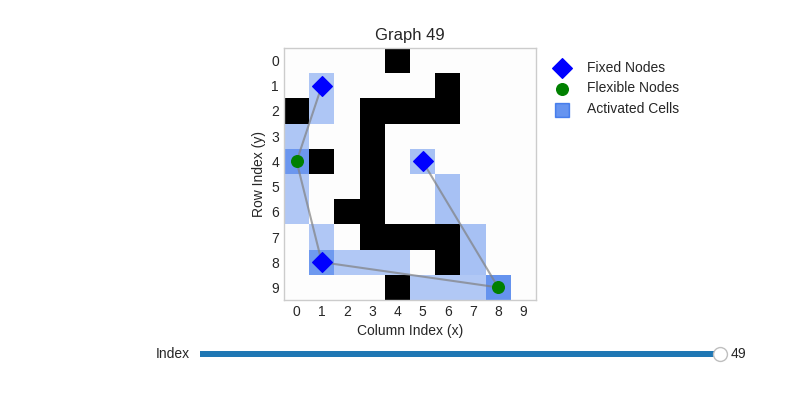

In [7]:
res = neatwork.run(
    config = neatwork.NEATCoreConfig(
        ngen=50,
        target_fit=60,
        population_size=400,
        species_threshold=0.8,
        special=neatwork.NWConfig(
            grid_size=cost_map.shape,
            fixed_nodes=fixed_nodes,
        ),
    ),
    eval_config=neatwork.EvalConfig(
        cost_map=cost_map,
        objectives=[neatwork.Objective.CostMap],
        constraints=[],
    ),
)

plotting.plot_graph_evolution([
    plotting.network_to_plot_graph(network=n, cost_map=cost_map) for n in res.top_networks
])

## The Rust Implementation

To run this, you must first build the Rust-based NEAT-core and NEATWork libraries. For that, you need to have Maturin installed. Then, you can run:

```bash
cd crates/neatwork_lib
maturin develop --release
cd ..
```

Gen 0001 | Avg fit -00.2395 | Top fit -00.1211 | Species 1 | top species: -00.1211
Gen 0002 | Avg fit -00.2094 | Top fit -00.0644 | Species 1 | top species: -00.0644
Gen 0003 | Avg fit -00.1719 | Top fit -00.0635 | Species 1 | top species: -00.0635
Gen 0004 | Avg fit -00.1651 | Top fit -00.0629 | Species 1 | top species: -00.0629
Gen 0005 | Avg fit -00.1703 | Top fit -00.0148 | Species 1 | top species: -00.0148
Gen 0006 | Avg fit -00.1602 | Top fit -00.0148 | Species 1 | top species: -00.0148
Gen 0007 | Avg fit -00.1405 | Top fit -00.0144 | Species 1 | top species: -00.0144
Gen 0008 | Avg fit -00.1186 | Top fit -00.0144 | Species 1 | top species: -00.0144
Gen 0009 | Avg fit -00.1291 | Top fit -00.0144 | Species 1 | top species: -00.0144
Gen 0010 | Avg fit -00.1377 | Top fit -00.0144 | Species 1 | top species: -00.0144
Gen 0011 | Avg fit -00.1327 | Top fit -00.0144 | Species 1 | top species: -00.0144
Gen 0012 | Avg fit -00.1538 | Top fit -00.0144 | Species 1 | top species: -00.0144
Gen 

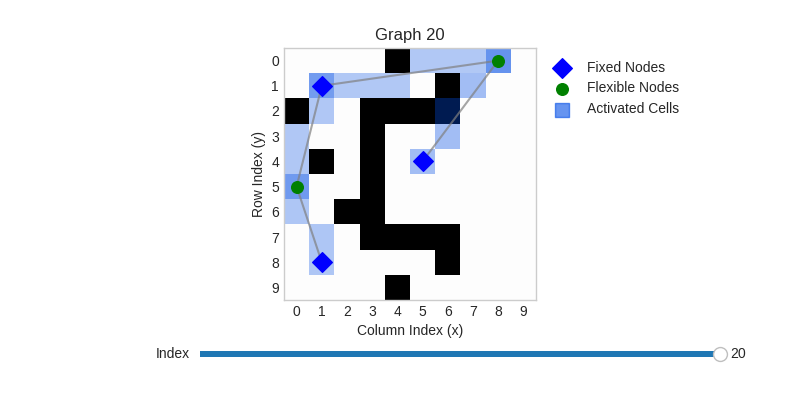

In [8]:
# the same benchmark using the Rust implementation

from neatwork import neatwork_rs

res = neatwork_rs.run(
    config=neatwork_rs.NEATCoreConfig(
        ngen=20,
        population_size=500,
        species_threshold=2,
            special=neatwork_rs.NWConfig(
            grid_size=cost_map.shape,
            fixed_nodes=fixed_nodes,
        ),
    ),
    eval_config=neatwork_rs.EvalConfig(
        cost_map=cost_map,
    ),
)

plotting.plot_graph_evolution([
    plotting.network_to_plot_graph(
        network=n,
        cost_map=cost_map,
    )
    for n in res.top_networks
])